 # 1. Title and objective
 This notebook presents a structured exploratory review of the Ames Housing dataset. The objective is to document data loading, variable profiling, metadata parsing, missing-value inspection, and numerical quality reporting in a readable analytical sequence.


 ## 2. Imports and setup
 The following imports provide the core tools used for data handling and text parsing in the initial stages of the notebook.


In [41]:

import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency

 ## 3. Data loading
 The dataset is loaded from the project data directory and an initial preview is displayed.


In [42]:
data_path= '../data/raw/AmesHousing.csv'

df = pd.read_csv(data_path)

df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [43]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2051, 81) (2051,)
Validation: (439, 81) (439,)
Test: (440, 81) (440,)


In [44]:
df_train = df.loc[X_train.index]

 ## 4. Initial dataset overview
 The next outputs summarize the dataset dimensions and a general descriptive overview of the available variables.


In [45]:
print(f'Dataset shape: {df.shape} :')

Dataset shape: (2930, 82) :


In [46]:
df.describe()


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


 ## 5. Variable profiling table
 This section constructs a compact profiling table for all variables, including completeness, cardinality, type, and simple count summaries.


In [47]:

def summary_profiling_table(df):
    summary = []

    for col in df.columns:
        series = df[col]

        num_values = series.notna().sum()
        pct_missing = series.isna().mean() * 100
        unique_vals = series.nunique(dropna=True)

        mean_val = series.mean() if pd.api.types.is_numeric_dtype(series) else np.nan
        python_type = series.dtype

        float_count = series.apply(lambda x: isinstance(x, float)).sum()
        int_count = series.apply(lambda x: isinstance(x, int)).sum()
        str_count = series.apply(lambda x: isinstance(x, str)).sum()

        summary.append([
            col,
            num_values,
            pct_missing,
            unique_vals,
            mean_val,
            python_type,
            float_count,
            int_count,
            str_count
        ])

    columns = [
        "variable",
        "num_of_values",
        "pct_missing",
        "unique_values",
        "mean",
        "python_type",
        "float_count",
        "int_count",
        "str_count"
    ]

    return pd.DataFrame(summary, columns=columns)


profiling_table = summary_profiling_table(df)
profiling_table


,variable,num_of_values,pct_missing,unique_values,mean,python_type,float_count,int_count,str_count
0,Order,2930,0.000000,2930,1.465500e+03,int64,0,2930,0
1,PID,2930,0.000000,2930,7.144645e+08,int64,0,2930,0
2,MS SubClass,2930,0.000000,16,5.738737e+01,int64,0,2930,0
3,MS Zoning,2930,0.000000,7,NaN,str,0,0,2930
4,Lot Frontage,2440,16.723549,128,6.922459e+01,float64,2930,0,0
...,...,...,...,...,...,...,...,...,...
77,Mo Sold,2930,0.000000,12,6.216041e+00,int64,0,2930,0
78,Yr Sold,2930,0.000000,5,2.007790e+03,int64,0,2930,0
79,Sale Type,2930,0.000000,10,NaN,str,0,0,2930
80,Sale Condition,2930,0.000000,6,NaN,str,0,0,2930


 ## 6. Metadata loading and parsing
The metadata file is parsed into a tabular structure to support comparison between documented variables and observed dataset fields.


In [48]:

def load_metadata_table(filepath: str) -> pd.DataFrame:
    """
    Parse Ames Housing metadata file and return a structured table
    with Variable Name, Variable Type, and Description.

    Parameters
    ----------
    filepath : str
        Path to metadata.txt file.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - Variable
        - Type
        - Description
    """

    variables = []

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    pattern = re.compile(r"^(.+?)\s*\((Nominal|Ordinal|Discrete|Continuous)\):\s*(.+)")

    for line in lines:
        match = pattern.match(line.strip())
        if match:
            var_name = match.group(1).strip()
            var_type = match.group(2).strip()
            description = match.group(3).strip()

            variables.append({
                "Variable": var_name,
                "Type": var_type,
                "Description": description
            })

    df = pd.DataFrame(variables)

    return df

In [49]:
metadata_df = load_metadata_table("../metada.txt")

In [50]:
metadata_df


,Variable,Type,Description
0,Order,Discrete,Observation number
1,PID,Nominal,Parcel identification number - can be used wi...
2,MS SubClass,Nominal,Identifies the type of dwelling involved in th...
3,MS Zoning,Nominal,Identifies the general zoning classification o...
4,Lot Frontage,Continuous,Linear feet of street connected to property
...,...,...,...
75,Mo Sold,Discrete,Month Sold (MM)
76,Yr Sold,Discrete,Year Sold (YYYY)
77,Sale Type,Nominal,Type of sale
78,Sale Condition,Nominal,Condition of sale


 ## 7. Missing values overview
 The following cells identify columns with missing values and provide a concise overview of their presence in the dataset.


In [51]:
def missing_columns(df):
    """
    Retorna uma lista de colunas ordenadas
    do maior número de missing values para o menor.
    """

    missing = (
        df.isna()
          .sum()                # conta missing por coluna
          .sort_values(ascending=False)  # ordena (maior → menor)
    )

    # mantém apenas colunas com missing
    missing = missing[missing > 0]

    return missing.index.tolist()

In [52]:
missing=missing_columns(df)

In [53]:
print(missing)

['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu', 'Lot Frontage', 'Garage Qual', 'Garage Yr Blt', 'Garage Cond', 'Garage Finish', 'Garage Type', 'Bsmt Exposure', 'BsmtFin Type 2', 'Bsmt Qual', 'Bsmt Cond', 'BsmtFin Type 1', 'Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Total Bsmt SF', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Garage Area', 'Garage Cars', 'Bsmt Unf SF', 'Electrical']


In [54]:
len(missing)


27

 ## 8. Detailed inspection of columns with missing values
 This inspection step lists value frequencies and unique entries for each variable that contains missing observations.


In [55]:
for col in df.columns:
    if col in missing:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))
        print(df[col].unique())


===== Lot Frontage =====
Lot Frontage
NaN      490
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
168.0      1
111.0      1
131.0      1
153.0      1
133.0      1
Name: count, Length: 129, dtype: int64
[141.  80.  81.  93.  74.  78.  41.  43.  39.  60.  75.  nan  63.  85.
  47. 152.  88. 140. 105.  65.  70.  26.  21.  53.  24. 102.  98.  83.
  94.  95.  90.  79. 100.  44. 110.  61.  36.  67. 108.  59.  92.  58.
  56.  73.  72.  84.  76.  50.  55.  68. 107.  25.  30.  57.  40.  77.
 120. 137.  87. 119.  64.  96.  71.  69.  52.  51.  54.  86. 124.  82.
  38.  48.  89.  66.  45.  35. 129.  31.  42.  28.  99. 104.  97. 103.
  34. 117. 149. 122.  62. 174. 106. 112.  32. 115. 128.  91.  33. 121.
 144. 130. 109. 150. 113. 125. 101.  46. 114. 135. 136.  37.  22. 313.
  49. 123. 160. 195. 118. 134. 182. 116. 138. 155. 126. 200. 168. 111.
 131. 153. 133.]

===== Alley =====
Alley
NaN     2732
Grvl     120
Pave      78
Name: count, dtype: int64
<StringArray>
[nan, 'Pave', 'Grvl

 ## 9. Structural vs non-structural missing values
 This section separates missing values that are structurally justified by metadata or variable families from those without such justification.


In [56]:

def extrair_variaveis_com_na(metadata_texto, df):
    """
    Retorna duas listas a partir das variáveis com NaN no dataset:
    - estrutural: NA justificado pelo metadata (explícito) OU pertence
                  à família Bsmt/Garage/MasVnr (implícito por proximidade)
    - nao_justificado: NaN sem qualquer justificação no metadata
    """
    variavel_pattern = re.compile(r'^([\w\s./-]+)\s*\([^\)]+\)\s*:', re.MULTILINE)
    na_pattern = re.compile(r'^\s*(NA|None)(\s|$)', re.MULTILINE)
    blocos = re.split(r'\n(?=\S[\w\s./-]*\s*\([^\)]+\)\s*:)', metadata_texto)

    # NA explícito no metadata
    na_explicito = []
    for bloco in blocos:
        m = variavel_pattern.match(bloco)
        if m and na_pattern.search(bloco):
            na_explicito.append(m.group(1).strip())

    # Famílias com NA implícito por proximidade
    familias = [r'(?i)bsmt', r'(?i)basement', r'(?i)garage', r'(?i)mas.?vnr']

    vars_com_nan = [col for col in df.columns if df[col].isna().any()]

    estrutural, nao_justificado = [], []
    for var in vars_com_nan:
        if var in na_explicito or any(re.search(p, var) for p in familias):
            estrutural.append(var)
        else:
            nao_justificado.append(var)

    return estrutural, nao_justificado


# Uso
with open("../metada.txt", "r", encoding="utf-8") as f:
    metadata_texto = f.read()

estrutural, nao_justificado = extrair_variaveis_com_na(metadata_texto, df)
  # → ['Lot Frontage', 'Electrical']
estrutural.append('Fireplace Qu')
nao_justificado.remove('Fireplace Qu')
print("Estrutural (justificado):", estrutural)
print("Não justificado:", nao_justificado)

Estrutural (justificado): ['Alley', 'Mas Vnr Type', 'Mas Vnr Area', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature', 'Fireplace Qu']
Não justificado: ['Lot Frontage', 'Electrical']


 ## 10. Targeted assessment of MCAR plausibility
 A targeted statistical procedure is defined below to examine whether selected missingness patterns are compatible with an MCAR assumption.


In [57]:


def test_mcar_targeted(df, target_var, candidate_predictors, verbose=True):
    """
    Tests MCAR for target_var using only theoretically motivated predictors.
    Much more reliable than kitchen-sink logistic regression.

    Returns dict with test results and interpretation.
    """
    df = df.copy()

    missing_indicator = df[target_var].isna().astype(int)
    n_missing = missing_indicator.sum()

    if n_missing < 10:
        return {
            "target": target_var,
            "verdict": "SKIP — too few missing values for reliable test",
            "n_missing": n_missing,
            "recommendation": "Assume MCAR, impute with mode/median"
        }

    results = {"target": target_var, "n_missing": n_missing, "tests": {}}

    for pred in candidate_predictors:
        if pred not in df.columns:
            continue

        col = df[pred]

        # Numeric: compare mean between missing vs non-missing (t-test)
        if pd.api.types.is_numeric_dtype(col):
            group0 = col[missing_indicator == 0].dropna()
            group1 = col[missing_indicator == 1].dropna()
            if len(group1) < 5:
                continue
            stat, p = stats.ttest_ind(group0, group1)
            results["tests"][pred] = {
                "test": "t-test",
                "mean_present": group0.mean(),
                "mean_missing": group1.mean(),
                "p_value": p
            }

        # Categorical: chi-square test of independence
        else:
            ct = pd.crosstab(col, missing_indicator)
            if ct.shape[0] < 2:
                continue
            chi2, p, dof, _ = stats.chi2_contingency(ct)
            results["tests"][pred] = {
                "test": "chi2",
                "chi2": chi2,
                "p_value": p
            }

    # Summarize
    sig = {k: v for k, v in results["tests"].items() if v["p_value"] < 0.05}
    results["significant_predictors"] = list(sig.keys())
    results["verdict"] = "MAR (not MCAR)" if sig else "Cannot reject MCAR"

    if verbose:
        print(f"\n{'='*50}")
        print(f"Variable: {target_var}  |  Missing: {n_missing} ({n_missing/len(df):.1%})")
        print(f"Verdict: {results['verdict']}")
        for pred, t in results["tests"].items():
            flag = " *** SIGNIFICANT" if t["p_value"] < 0.05 else ""
            print(f"  {pred}: p={t['p_value']:.4f}{flag}")

    return results


# ── Apply ──────────────────────────────────────────────────────────────────

hypotheses = {
    "Lot Frontage": ["Lot Config", "Lot Shape", "Neighborhood", "Bldg Type", "MS SubClass"],
    "Electrical":   []  # skip — only 1 missing
}

for var, preds in hypotheses.items():
    if not preds:
        print(f"\nElectrical: 1 missing value → assume MCAR, impute with mode")
        continue
    test_mcar_targeted(df, var, preds)


Variable: Lot Frontage  |  Missing: 490 (16.7%)
Verdict: MAR (not MCAR)
  Lot Config: p=0.0000 *** SIGNIFICANT
  Lot Shape: p=0.0000 *** SIGNIFICANT
  Neighborhood: p=0.0000 *** SIGNIFICANT
  Bldg Type: p=0.0065 *** SIGNIFICANT
  MS SubClass: p=0.2753

Electrical: 1 missing value → assume MCAR, impute with mode


 ## 11. Numerical variables quality report
 The next cells isolate numerical variables and generate descriptive quality indicators, including dispersion and distribution-shape measures.


In [58]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [59]:

def numeric_quality_report(df):

    numeric_df = df.select_dtypes(include=[np.number])

    summary = []

    for col in numeric_df.columns:
        s = numeric_df[col].dropna()

        if len(s) == 0:
            continue

        mean_val = s.mean()
        median_val = s.median()
        std_val = s.std()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        cv_val = std_val / mean_val
        iqr_val = q3 - q1
        skew_val = skew(s, bias=False)
        kurt_val = kurtosis(s, bias=False)  # excess kurtosis

        summary.append({
            "variable": col,
            "n": len(s),
            "mean": mean_val,
            "median": median_val,
            "mean_minus_median": mean_val - median_val,
            "std": std_val,
            "cv": cv_val,
            "IQR": iqr_val,
            "skewness": skew_val,
            "kurtosis_excess": kurt_val
        })

    result = pd.DataFrame(summary)

    # Opcional: ordenar por assimetria absoluta
    result = result.sort_values("skewness", key=lambda x: abs(x), ascending=False)

    return result

In [60]:
numeric_report = numeric_quality_report(df_train)
numeric_report.head(10)

,variable,n,mean,median,mean_minus_median,std,cv,IQR,skewness,kurtosis_excess
35,Misc Val,2051,61.570453,0.0,61.570453,660.885107,10.733803,0.0,19.515558,433.402621
34,Pool Area,2051,2.524622,0.0,2.524622,38.075237,15.081559,0.0,16.056906,269.635853
4,Lot Area,2051,10179.894198,9360.0,819.894198,8427.010496,0.827809,4098.0,13.618820,275.996093
16,Low Qual Fin SF,2051,4.473428,0.0,4.473428,45.966198,10.275387,0.0,12.869240,203.069554
32,3Ssn Porch,2051,2.619210,0.0,2.619210,25.832553,9.862726,0.0,11.696761,158.045033
23,Kitchen AbvGr,2051,1.046319,1.0,0.046319,0.217076,0.207466,0.0,4.457161,20.449131
11,BsmtFin SF 2,2050,49.428293,0.0,49.428293,169.431884,3.427832,0.0,4.304198,20.756018
31,Enclosed Porch,2051,25.211604,0.0,25.211604,67.404813,2.673563,0.0,3.974875,29.140229
19,Bsmt Half Bath,2050,0.060000,0.0,0.060000,0.239591,3.993175,0.0,3.814338,13.136297
33,Screen Porch,2051,15.841053,0.0,15.841053,54.304221,3.428069,0.0,3.617381,13.216780


In [61]:
numeric_report.info()

<class 'pandas.DataFrame'>
Index: 39 entries, 35 to 0
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   variable           39 non-null     str    
 1   n                  39 non-null     int64  
 2   mean               39 non-null     float64
 3   median             39 non-null     float64
 4   mean_minus_median  39 non-null     float64
 5   std                39 non-null     float64
 6   cv                 39 non-null     float64
 7   IQR                39 non-null     float64
 8   skewness           39 non-null     float64
 9   kurtosis_excess    39 non-null     float64
dtypes: float64(8), int64(1), str(1)
memory usage: 3.4 KB


 ## 12. Interpretation layer for numerical quality
 This layer assigns compact qualitative labels to the numerical quality metrics computed in the previous section.


In [62]:
def interpret_numeric_quality(df_report):
    """
    Recebe o dataframe do numeric_quality_report e adiciona colunas interpretativas
    para mean_minus_median, CV, skewness e kurtosis_excess.
    """
    import numpy as np

    report = df_report.copy()

    # --- Mean vs Median ---
    def mean_median_label(x, tol=1e-6):
        if pd.isna(x):
            return np.nan
        elif abs(x) < tol:
            return "Mean and median are approximately equal"
        elif x > 0:
            return "Mean greater than median (suggests positive skew)"
        else:
            return "Mean lower than median (suggests negative skew)"

    report["Mean_vs_median_interpretation"] = report["mean_minus_median"].apply(mean_median_label)

    # --- CV ---
    def cv_label(cv):
        if pd.isna(cv):
            return np.nan
        elif cv < 0.3:
            return "Low variability"
        elif cv < 0.7:
            return "Moderate variability"
        else:
            return "High variability"

    report["CV_interpretation"] = report["cv"].apply(cv_label)

    # --- Skewness ---
    def skew_label(sk):
        if pd.isna(sk):
            return np.nan

        abs_sk = abs(sk)

        if abs_sk < 0.5:
            magnitude = "Approximately symmetric"
        elif abs_sk < 1:
            magnitude = "Moderately skewed"
        else:
            magnitude = "Highly skewed"

        if sk > 0:
            direction = " (positive/right skew)"
        elif sk < 0:
            direction = " (negative/left skew)"
        else:
            direction = ""

        return magnitude + direction

    report["Skewness_interpretation"] = report["skewness"].apply(skew_label)

    # --- Kurtosis (excess kurtosis) ---
    def kurt_label(k):
        if pd.isna(k):
            return np.nan
        elif k < 0:
            return "Light tails (platykurtic)"
        elif abs(k) < 0.5:
            return "Approximately normal tails (mesokurtic)"
        elif k < 3:
            return "Moderately heavy tails"
        else:
            return "Heavy tails / extreme values"

    report["Kurtosis_interpretation"] = report["kurtosis_excess"].apply(kurt_label)

    # Selecionar colunas para interpretação
    interpretive_cols = [
        "variable",
        "mean",
        "median",
        "mean_minus_median",
        "Mean_vs_median_interpretation",
        "std",
        "cv",
        "CV_interpretation",
        "skewness",
        "Skewness_interpretation",
        "kurtosis_excess",
        "Kurtosis_interpretation"
    ]

    return report[interpretive_cols]

In [63]:
# Uso
numeric_report = numeric_quality_report(df_train)
numeric_interpretive = interpret_numeric_quality(numeric_report)
numeric_interpretive.head(39)


,variable,mean,median,mean_minus_median,Mean_vs_median_interpretation,std,cv,CV_interpretation,skewness,Skewness_interpretation,kurtosis_excess,Kurtosis_interpretation
35,Misc Val,6.157045e+01,0.0,6.157045e+01,Mean greater than median (suggests positive skew),6.608851e+02,10.733803,High variability,19.515558,Highly skewed (positive/right skew),433.402621,Heavy tails / extreme values
34,Pool Area,2.524622e+00,0.0,2.524622e+00,Mean greater than median (suggests positive skew),3.807524e+01,15.081559,High variability,16.056906,Highly skewed (positive/right skew),269.635853,Heavy tails / extreme values
4,Lot Area,1.017989e+04,9360.0,8.198942e+02,Mean greater than median (suggests positive skew),8.427010e+03,0.827809,High variability,13.618820,Highly skewed (positive/right skew),275.996093,Heavy tails / extreme values
16,Low Qual Fin SF,4.473428e+00,0.0,4.473428e+00,Mean greater than median (suggests positive skew),4.596620e+01,10.275387,High variability,12.869240,Highly skewed (positive/right skew),203.069554,Heavy tails / extreme values
32,3Ssn Porch,2.619210e+00,0.0,2.619210e+00,Mean greater than median (suggests positive skew),2.583255e+01,9.862726,High variability,11.696761,Highly skewed (positive/right skew),158.045033,Heavy tails / extreme values
23,Kitchen AbvGr,1.046319e+00,1.0,4.631887e-02,Mean greater than median (suggests positive skew),2.170756e-01,0.207466,Low variability,4.457161,Highly skewed (positive/right skew),20.449131,Heavy tails / extreme values
11,BsmtFin SF 2,4.942829e+01,0.0,4.942829e+01,Mean greater than median (suggests positive skew),1.694319e+02,3.427832,High variability,4.304198,Highly skewed (positive/right skew),20.756018,Heavy tails / extreme values
31,Enclosed Porch,2.521160e+01,0.0,2.521160e+01,Mean greater than median (suggests positive skew),6.740481e+01,2.673563,High variability,3.974875,Highly skewed (positive/right skew),29.140229,Heavy tails / extreme values
19,Bsmt Half Bath,6.000000e-02,0.0,6.000000e-02,Mean greater than median (suggests positive skew),2.395905e-01,3.993175,High variability,3.814338,Highly skewed (positive/right skew),13.136297,Heavy tails / extreme values
33,Screen Porch,1.584105e+01,0.0,1.584105e+01,Mean greater than median (suggests positive skew),5.430422e+01,3.428069,High variability,3.617381,Highly skewed (positive/right skew),13.216780,Heavy tails / extreme values


In [64]:
def overall_data_quality_table(numeric_report):

    results = []

    for _, row in numeric_report.iterrows():

        var = row["variable"]
        cv = row["cv"]
        skew = row["skewness"]
        kurt = row["kurtosis_excess"]

        # --- Validity assessment ---
        validity = "Likely valid and meaningful feature"

        # --- Modeling challenges ---
        challenges = []

        if cv >= 0.7:
            challenges.append("High dispersion")

        if abs(skew) >= 1:
            challenges.append("Strong skewness")
        elif abs(skew) >= 0.5:
            challenges.append("Moderate skewness")

        if kurt >= 3:
            challenges.append("Heavy tails")
        elif kurt > 0.5:
            challenges.append("Moderately heavy tails")

        if not challenges:
            modeling = "Statistically well-behaved"
        else:
            modeling = ", ".join(challenges)

        # --- Overall quality ---
        score = 0

        if cv >= 0.7:
            score += 1
        if abs(skew) >= 1:
            score += 1
        if kurt >= 3:
            score += 1

        if score == 0:
            overall = "High Quality"
        elif score == 1:
            overall = "Moderate Quality"
        else:
            overall = "Statistically Challenging"

        results.append({
            "variable": var,
            "validity_assessment": validity,
            "modeling_assessment": modeling,
            "overall_quality": overall
        })

    return pd.DataFrame(results)

In [65]:
quality_table = overall_data_quality_table(numeric_report)

quality_table

,variable,validity_assessment,modeling_assessment,overall_quality
0,Misc Val,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
1,Pool Area,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
2,Lot Area,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
3,Low Qual Fin SF,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
4,3Ssn Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
5,Kitchen AbvGr,Likely valid and meaningful feature,"Strong skewness, Heavy tails",Statistically Challenging
6,BsmtFin SF 2,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
7,Enclosed Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
8,Bsmt Half Bath,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
9,Screen Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging


In [66]:
def categorical_quality_report(df, rare_threshold=0.05):

    results = []

    cat_cols = df.select_dtypes(exclude="number").columns

    for col in cat_cols:

        s = df[col]

        counts = s.value_counts(dropna=False)
        rel_freq = s.value_counts(normalize=True, dropna=False)

        cardinality = s.nunique(dropna=True)

        dominant_pct = rel_freq.max() * 100

        rare_levels = rel_freq[rel_freq < rare_threshold]
        rare_count = len(rare_levels)

        rare_pct = rare_levels.sum() * 100

        missing_pct = s.isna().mean() * 100

        # --- imbalance evaluation ---
        if dominant_pct < 60:
            imbalance = "Balanced"
        elif dominant_pct < 80:
            imbalance = "Moderate imbalance"
        else:
            imbalance = "High imbalance"

        # --- cardinality evaluation ---
        if cardinality < 10:
            cardinality_level = "Low"
        elif cardinality <= 30:
            cardinality_level = "Moderate"
        else:
            cardinality_level = "High"

        # --- overall quality ---
        score = 0

        if dominant_pct > 80:
            score += 1

        if rare_count > 3:
            score += 1

        if cardinality > 30:
            score += 1

        if score == 0:
            overall = "High Quality"
        elif score == 1:
            overall = "Moderate Quality"
        else:
            overall = "Statistically Challenging"

        results.append({
            "variable": col,
            "cardinality": cardinality,
            "cardinality_level": cardinality_level,
            "dominant_pct": round(dominant_pct, 2),
            "rare_levels": rare_count,
            "rare_pct": round(rare_pct, 2),
            "missing_pct": round(missing_pct, 2),
            "imbalance": imbalance,
            "overall_quality": overall
        })

    return pd.DataFrame(results)

In [67]:
categorical_report = categorical_quality_report(df_train)

categorical_report

,variable,cardinality,cardinality_level,dominant_pct,rare_levels,rare_pct,missing_pct,imbalance,overall_quality
0,MS Zoning,7,Low,76.99,5,6.53,0.00,Moderate imbalance,Moderate Quality
1,Street,2,Low,99.51,1,0.49,0.00,High imbalance,Moderate Quality
2,Alley,2,Low,92.83,2,7.17,92.83,High imbalance,Moderate Quality
3,Lot Shape,4,Low,64.07,2,2.83,0.00,Moderate imbalance,High Quality
4,Land Contour,4,Low,90.05,3,9.95,0.00,High imbalance,Moderate Quality
5,Utilities,3,Low,99.85,2,0.15,0.00,High imbalance,Moderate Quality
6,Lot Config,5,Low,73.57,2,2.93,0.00,Moderate imbalance,High Quality
7,Land Slope,3,Low,95.17,2,4.83,0.00,High imbalance,Moderate Quality
8,Neighborhood,28,Moderate,15.70,20,38.76,0.00,Balanced,Moderate Quality
9,Condition 1,9,Low,85.67,7,8.43,0.00,High imbalance,Statistically Challenging


In [68]:
corr_pearson = df_train.corr(numeric_only=True)

corr_target_pearson = corr_pearson['SalePrice'].sort_values(ascending=False)
corr_target_pearson.head(20)

SalePrice         1.000000
Overall Qual      0.792383
Gr Liv Area       0.699668
Garage Cars       0.640817
Garage Area       0.625989
Total Bsmt SF     0.611201
1st Flr SF        0.605158
Full Bath         0.540405
Year Built        0.539592
Year Remod/Add    0.514574
Garage Yr Blt     0.510925
Mas Vnr Area      0.495818
TotRms AbvGrd     0.483349
Fireplaces        0.470472
BsmtFin SF 1      0.416927
Wood Deck SF      0.337257
Lot Frontage      0.333727
Half Bath         0.298273
Open Porch SF     0.292226
2nd Flr SF        0.291351
Name: SalePrice, dtype: float64

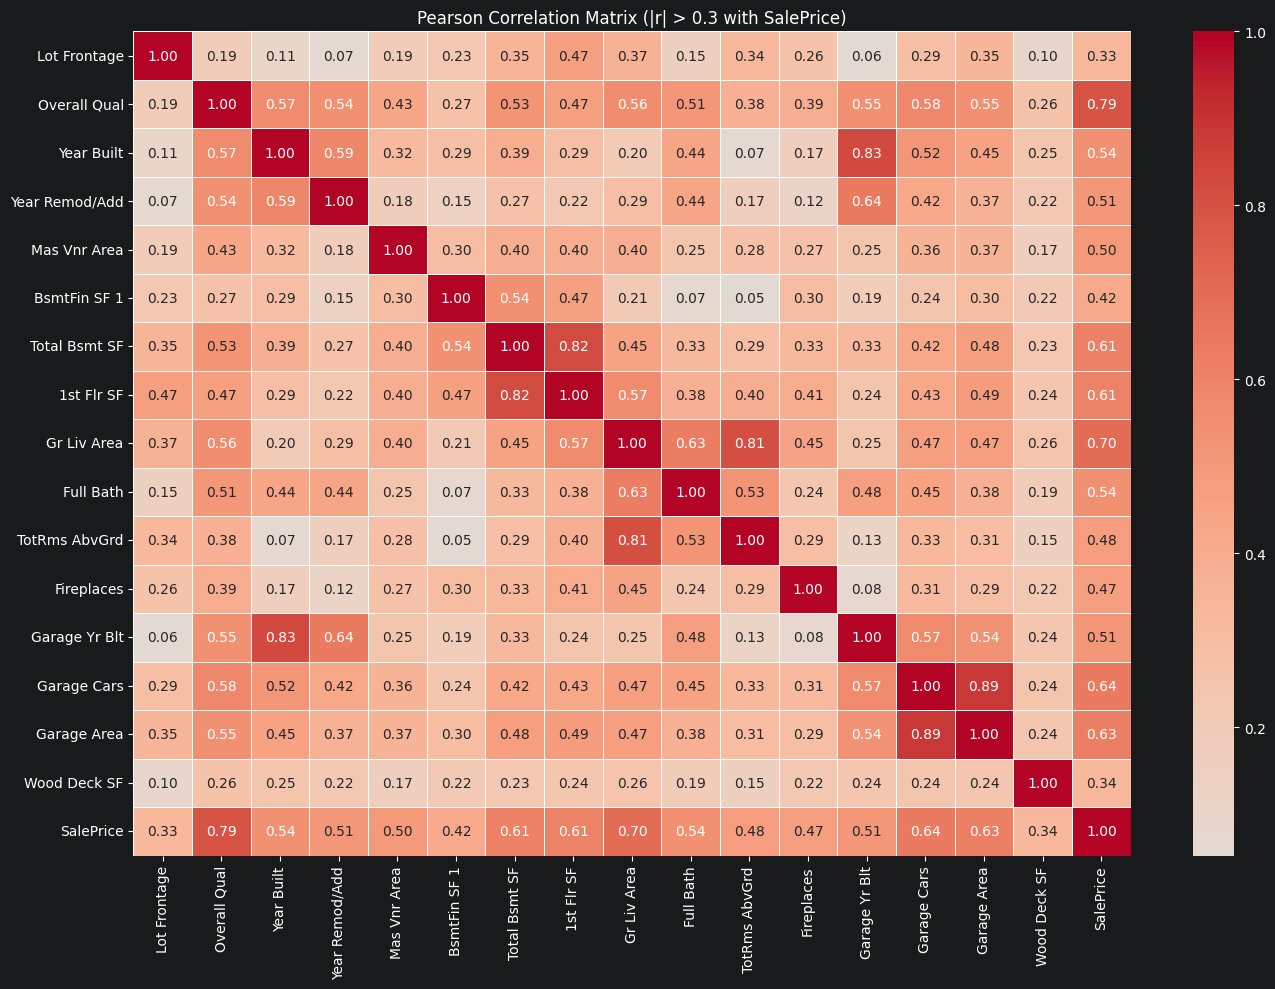

In [69]:
high_corr_cols = corr_pearson.index[corr_pearson['SalePrice'].abs() > 0.3].tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_pearson.loc[high_corr_cols, high_corr_cols],
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix (|r| > 0.3 with SalePrice)")
plt.tight_layout()
plt.show()

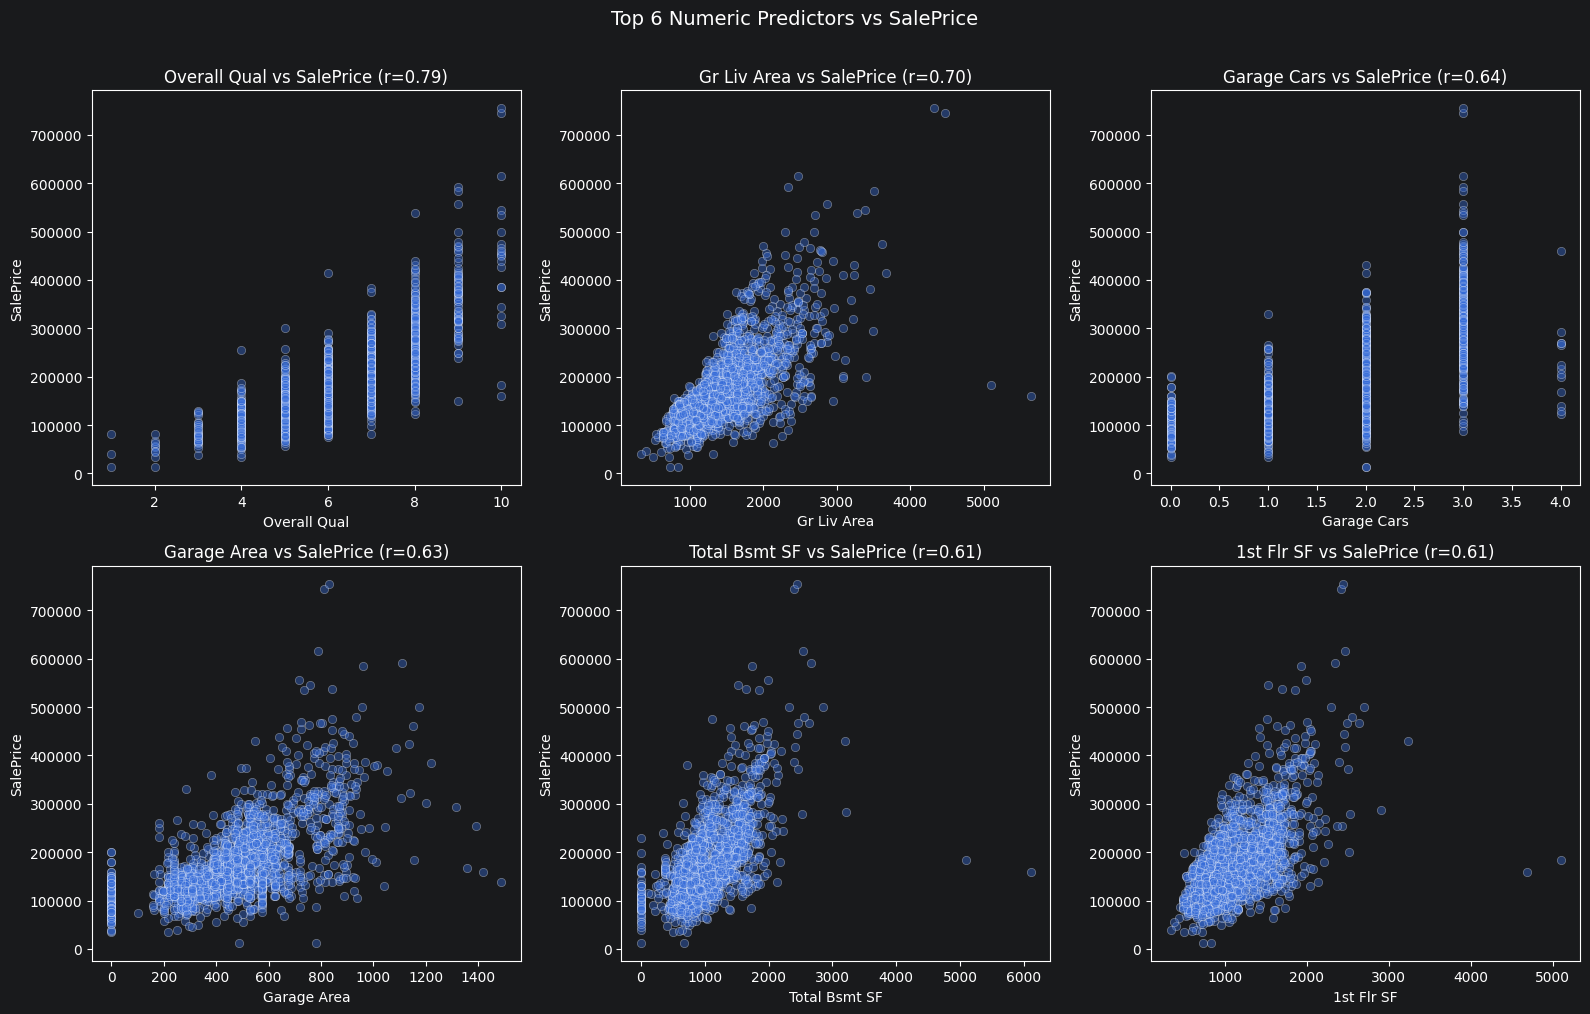

In [70]:
top_predictors = corr_target_pearson.drop('SalePrice').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    sns.scatterplot(data=df_train, x=col, y='SalePrice', alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{col} vs SalePrice (r={corr_target_pearson[col]:.2f})")

plt.suptitle("Top 6 Numeric Predictors vs SalePrice", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [71]:
corr_spearman = df_train.corr(method='spearman', numeric_only=True)

corr_target_spearman = corr_spearman['SalePrice'].sort_values(ascending=False)

comparison = pd.DataFrame({
    'Pearson': corr_target_pearson,
    'Spearman': corr_target_spearman
}).dropna().sort_values('Spearman', ascending=False)

comparison.head(20)

,Pearson,Spearman
SalePrice,1.000000,1.000000
Overall Qual,0.792383,0.795160
Gr Liv Area,0.699668,0.713168
Garage Cars,0.640817,0.688374
Year Built,0.539592,0.662405
Garage Area,0.625989,0.640192
Full Bath,0.540405,0.634390
Garage Yr Blt,0.510925,0.610081
Total Bsmt SF,0.611201,0.593039
Year Remod/Add,0.514574,0.580433


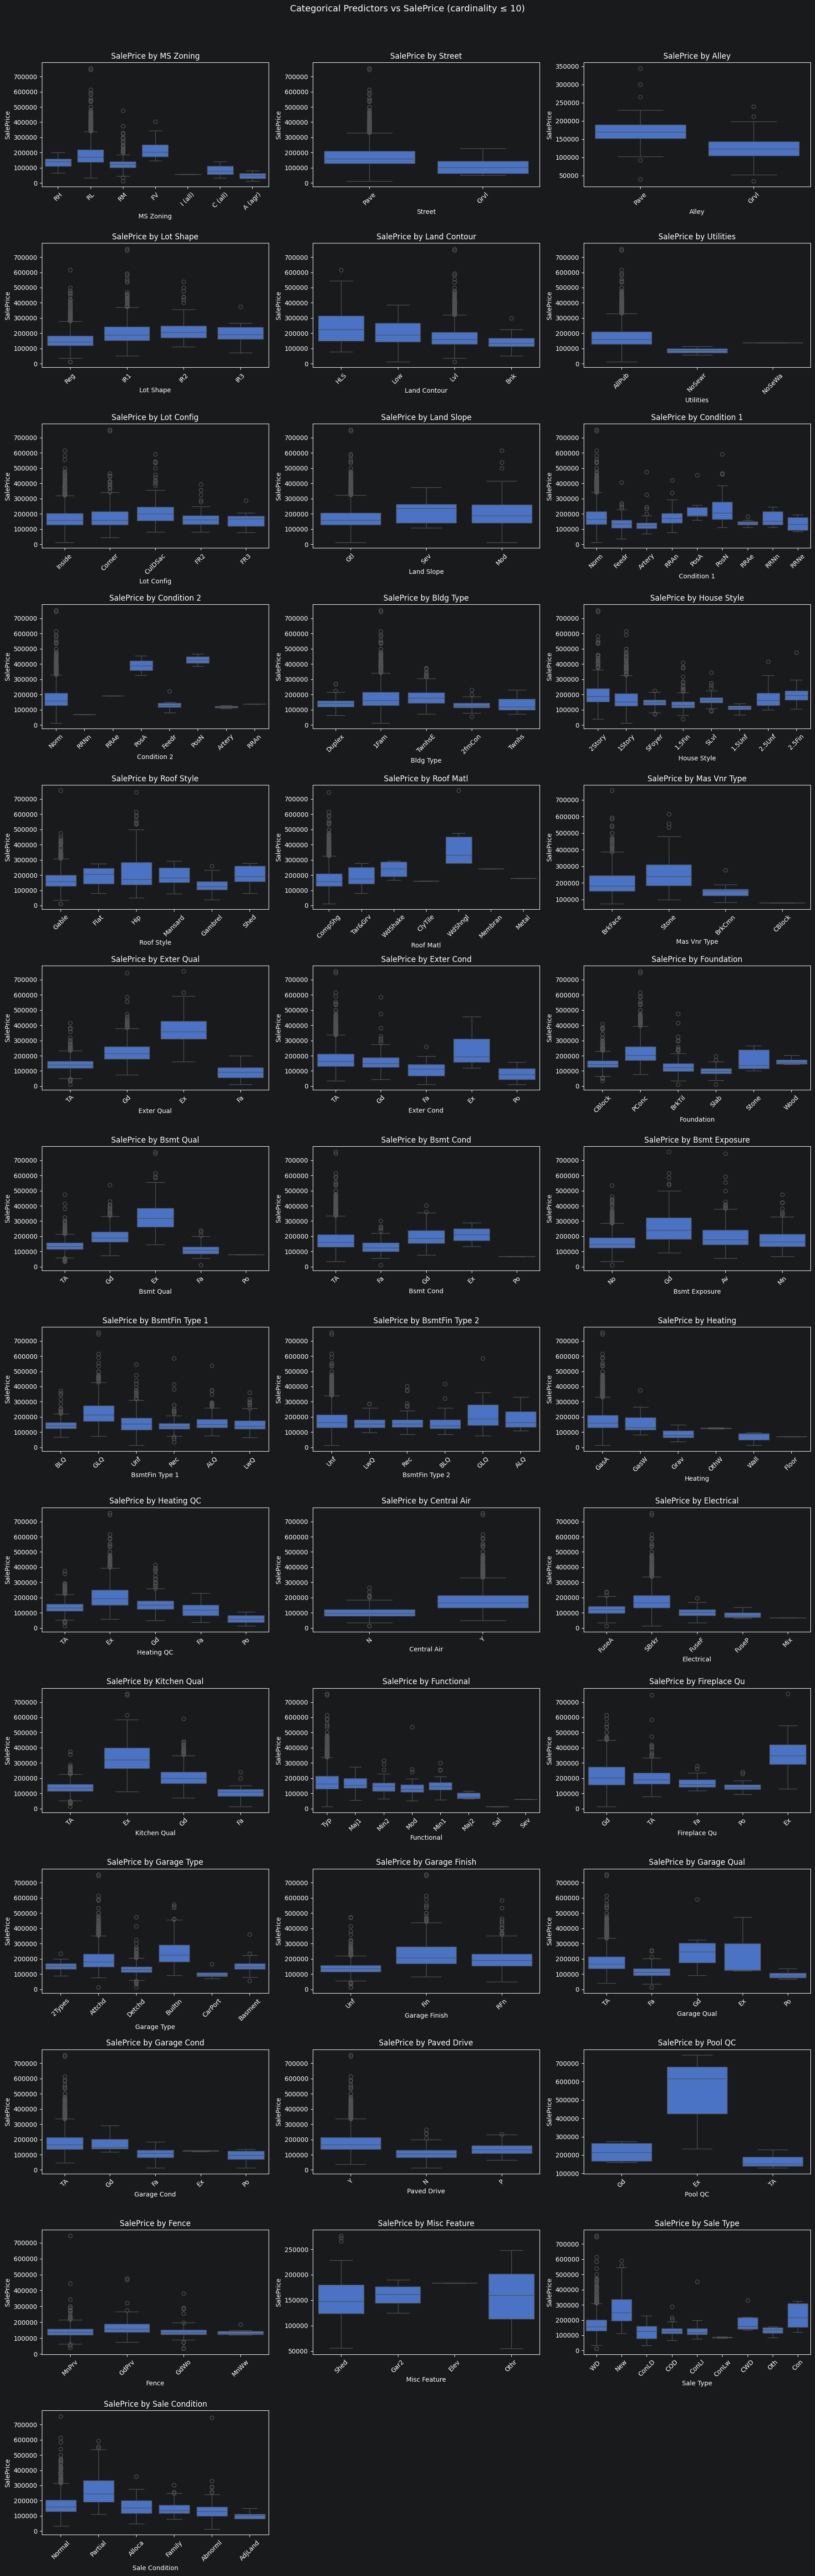

In [72]:
cat_cols_low_card = categorical_report[categorical_report['cardinality'] <= 10]['variable'].tolist()

n = len(cat_cols_low_card)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_low_card):
    sns.boxplot(data=df_train, x=col, y='SalePrice', ax=axes[i])
    axes[i].set_title(f"SalePrice by {col}")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Predictors vs SalePrice (cardinality ≤ 10)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [73]:
vif_candidates = corr_target_pearson.drop('SalePrice').abs().sort_values(ascending=False).head(10).index.tolist()

X_vif = df_train[vif_candidates].dropna()
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df = vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False)
vif_df

,variable,VIF
3,Garage Cars,4.127927
10,Garage Yr Blt,4.092846
4,Garage Area,4.052786
6,1st Flr SF,3.884516
8,Year Built,3.805353
5,Total Bsmt SF,3.681784
2,Gr Liv Area,2.667504
1,Overall Qual,2.440029
7,Full Bath,2.191795
9,Year Remod/Add,1.921172


In [74]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    n = table.sum().sum()
    k = min(table.shape)
    if k <= 1:
        return np.nan
    chi2, p, dof, _ = chi2_contingency(table)
    return np.sqrt(chi2 / (n * (k - 1)))

cat_cols_for_cramers = categorical_report[categorical_report['cardinality'] <= 15]['variable'].tolist()

pairs = []
for i, col1 in enumerate(cat_cols_for_cramers):
    for col2 in cat_cols_for_cramers[i+1:]:
        v = cramers_v(df_train[col1], df_train[col2])
        if not np.isnan(v):
            pairs.append({'var1': col1, 'var2': col2, 'cramers_v': round(v, 3)})

cramers_pairs = pd.DataFrame(pairs).sort_values('cramers_v', ascending=False)
cramers_pairs.head(20)

,var1,var2,cramers_v
615,Foundation,Pool QC,0.829
1,MS Zoning,Alley,0.778
692,BsmtFin Type 1,Pool QC,0.771
411,House Style,Pool QC,0.764
787,Functional,Pool QC,0.750
521,Exterior 2nd,Pool QC,0.736
495,Exterior 1st,Pool QC,0.722
473,Exterior 1st,Exterior 2nd,0.718
548,Mas Vnr Type,Misc Feature,0.711
797,Fireplace Qu,Pool QC,0.687


 ## 13. Preliminary findings
 The notebook now consolidates the main descriptive outputs related to variable profiling, metadata structure, missingness patterns, and numerical quality summaries.


 ## 14. Next steps
 These organized outputs provide a basis for subsequent preprocessing and modeling stages in the broader project workflow.
